# IS 346: Data Quality - Project
**Prepared by:** Alanoud Alotaibi 445202172 , Najd Altamimi 444201287

**Supervise by:** Dr.Nouf Aldrees

**loading dataset and libraries**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Load dataset
path = kagglehub.dataset_download("nudratabbas/messy-clinic-appointments-dataset")
file_path = os.path.join(path, 'messy_clinic_appointments.csv')
df = pd.read_csv(file_path)

# 2. Dataset Description
print("DATASET DESCRIPTION")
print("="*50)
desc = """
Attribute            | Description
patient_id           | Unique patient identifier
patient_name         | Full name of the patient
age                  | Age of the patient
gender               | Gender (Male/Female)
appointment_date     | Intended appointment date (dd/mm/yyyy)
booking_date         | Date the appointment was booked
doctor               | Assigned doctor name
department           | Medical department
billing_amount       | Consultation fee (should be numeric)
follow_up_required   | Whether follow-up is needed (Yes/No)
"""
print(desc)


100%|██████████| 30.2k/30.2k [00:00<00:00, 28.6MB/s]

Extracting files...
DATASET DESCRIPTION

Attribute            | Description
patient_id           | Unique patient identifier
patient_name         | Full name of the patient
age                  | Age of the patient
gender               | Gender (Male/Female)
appointment_date     | Intended appointment date (dd/mm/yyyy)
booking_date         | Date the appointment was booked
doctor               | Assigned doctor name
department           | Medical department
billing_amount       | Consultation fee (should be numeric)
follow_up_required   | Whether follow-up is needed (Yes/No)



**Data Profiling**

DATA PROFILING

Shape: 1000 rows × 10 columns
Columns: ['patient_id', 'patient_name', 'age', 'gender', 'appointment_date', 'booking_date', 'doctor', 'department', 'billing_amount', 'follow_up_required']

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,1000.0,NaN,NaN,NaN,1050.521,28.888581,1000.0,1025.0,1051.0,1075.0,1100.0
patient_name,1000,988,Thomas Smith,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,53.75,21.137604,18.0,34.0,55.0,71.0,90.0
gender,950,8,0,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,1000,735,2026/02/11,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,1000,822,21-Jul-2025,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doctor,1000,990,Nancy Hernandez,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1000,4,Neurology,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_amount,950,949,€243.78,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
follow_up_required,1000,6,0,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Missing Values ---


,Column,Missing Count,% Missing
8,billing_amount,50,5.0
3,gender,50,5.0



Exact duplicate rows: 0
Duplicate patient IDs: 899

Gender errors (not strictly Male/Female): 707
Billing amount non-numeric: 950
Age out of 0-120: 0
Appointment date format errors: 908, future dates: 16

--- gender top values ---
gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
NaN        50
Name: count, dtype: int64

--- doctor top values ---
doctor
Nancy Hernandez      2
Nancy Wilson         2
Wesley Johnson       2
Kristen Lopez        2
James Aguilar        2
Christopher Smith    2
Benjamin Brown       2
Jennifer Adams       2
Jennifer Carroll     2
Michael Wright       2
Name: count, dtype: int64

--- department top values ---
department
Neurology      273
Orthopedics    262
Cardiology     234
General        231
Name: count, dtype: int64

--- follow_up_required top values ---
follow_up_required
0      185
Y      182
Yes    181
N      154
1      151
No     147
Name: count, dtype: int64


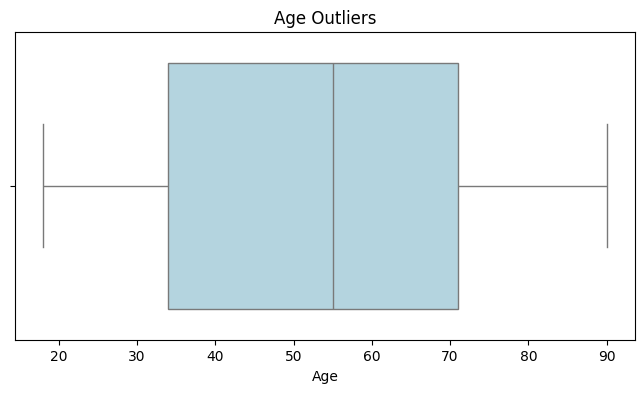

In [2]:
# 3. Data Profiling
print("DATA PROFILING")
print("="*50)

# From DataQuality (SHAPE OF DATASET)
print("\n--- Dataset Shape & Columns ---")
print("Columns in dataset:", df.columns.tolist())
num_records = df.shape[0]
num_attributes = df.shape[1]
print(f"The Dataset has {num_attributes} attributes, {num_records} instances.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Basic statistics (min, max, average)
print("\n--- Descriptive Statistics (All Columns) ---")
display(df.describe(include='all').T)
print("\n--- Descriptive Statistics (Numeric Columns Only) ---")
display(df.describe()) # note here take screenshot for pdf report

# Missing values
print("\n--- Missing Values Details ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    '% Missing': missing_pct.values
}).sort_values('Missing Count', ascending=False)
display(missing_table[missing_table['Missing Count'] > 0])

print("Missing values summary (only columns with missing data):")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

# Duplicates
print("\n--- Duplicates ---")
exact_dups = df.duplicated().sum()
id_dups = df['patient_id'].duplicated().sum()
print(f"Exact duplicate rows: {exact_dups}")
print(f"Duplicate patient IDs: {id_dups}")
print(f"Total fully duplicated rows in the dataset: {exact_dups}")
print(f"Total duplicate Patient IDs: {id_dups} (important to not have duplicate in ID)")

# Validity & Inconsistency Issues
print("\n--- Validity & Inconsistency Issues ---")

# Gender
strict_genders = ['Male', 'Female']
gender_err = (~df['gender'].isin(strict_genders) & df['gender'].notnull()).sum()
print(f"Gender errors (not strictly Male/Female): {gender_err}")
print(f"Total Gender errors (violates strict 'Male'/'Female' standard): {gender_err}")

# Billing amount
numeric_billing = pd.to_numeric(df['billing_amount'], errors='coerce')
billing_non_numeric = (numeric_billing.isnull() & df['billing_amount'].notnull()).sum()
print(f"Billing amount non-numeric: {billing_non_numeric}")
print(f"Total invalid Billing Amounts (contains text/symbols): {billing_non_numeric}")

# Age range (0-120)
age_out_of_range = ((df['age'] < 0) | (df['age'] > 120)).sum()
print(f"Age out of 0-120: {age_out_of_range}")

# Appointment date format & future
appt_dates = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
appt_fmt_err = (appt_dates.isnull() & df['appointment_date'].notnull()).sum()
appt_future = (appt_dates > pd.Timestamp.today()).sum()
print(f"Appointment date format errors: {appt_fmt_err}, future dates: {appt_future}")

# Categorical columns – top values
for col in ['gender','doctor','department','follow_up_required']:
    print(f"\n--- {col} top values ---")
    print(df[col].value_counts(dropna=False).head(10))

# Outliers Plot
print("\n--- Outliers Chart (Age) ---")
# 1. Seaborn Boxplot (from IS346)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['age'].dropna(), color='lightblue')
plt.title('Age Outliers (Seaborn)')
plt.xlabel('Age')
plt.show()

# 2. Matplotlib Boxplot (from DataQuality)
plt.figure(figsize=(8, 4))
plt.boxplot(df['age'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Age Outliers (Matplotlib)', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.gca().set_facecolor('white')
plt.show()


**Classification of Data Quality Issues**

In [3]:
followup_fail = (~df['follow_up_required'].isin(['Yes','No']) & df['follow_up_required'].notnull()).sum()
expected_depts = ['Cardiology','Neurology','Orthopedics','Pediatrics','General']
dept_fail = (~df['department'].isin(expected_depts) & df['department'].notnull()).sum()

classification_df = pd.DataFrame([
    ["Completeness", "Missing gender values", f"{df['gender'].isnull().sum()} records"],
    ["Completeness", "Missing billing_amount values", f"{df['billing_amount'].isnull().sum()} records"],
    ["Uniqueness", "Duplicate patient IDs (should be unique)", f"{df['patient_id'].duplicated().sum()} duplicates"],
    ["Validity", "Gender not 'Male'/'Female'", f"{(~df['gender'].isin(['Male','Female']) & df['gender'].notnull()).sum()} records"],
    ["Validity", "Billing amount contains text/symbols", f"{(pd.to_numeric(df['billing_amount'], errors='coerce').isnull() & df['billing_amount'].notnull()).sum()} records"],
    ["Validity", "Age outside plausible range (0-120)", f"{((df['age'] < 0) | (df['age'] > 120)).sum()} records"],
    ["Consistency", "Appointment date invalid format", f"{(pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce').isnull() & df['appointment_date'].notnull()).sum()} records"],
    ["Consistency", "Future appointment dates", f"{(pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce') > pd.Timestamp.today()).sum()} records"],
    ["Consistency", "Department values not in expected list", f"{dept_fail} records"],
    ["Consistency", "Follow-up not Yes/No", f"{followup_fail} records"]
], columns=["Category", "Issue Description", "Extent"])

print("CLASSIFICATION OF DATA QUALITY ISSUES")
print("="*70)
display(classification_df)

CLASSIFICATION OF DATA QUALITY ISSUES


,Category,Issue Description,Extent
0,Completeness,Missing gender values,50 records
1,Completeness,Missing billing_amount values,50 records
2,Uniqueness,Duplicate patient IDs (should be unique),899 duplicates
3,Validity,Gender not 'Male'/'Female',707 records
4,Validity,Billing amount contains text/symbols,950 records
5,Validity,Age outside plausible range (0-120),0 records
6,Consistency,Appointment date invalid format,908 records
7,Consistency,Future appointment dates,16 records
8,Consistency,Department values not in expected list,0 records
9,Consistency,Follow-up not Yes/No,672 records


**Quality Checks Implementation**

QUALITY CHECKS IMPLEMENTATION

Note: No email column in dataset

--- Data Quality Check Summary ---


,Check,Failed Records
0,Billing Format (Currency),950
1,Appt Date Invalid,924
2,Duplicate IDs,899
3,Gender Format,707
4,Follow-up Format,672
5,Missing Names,0
6,Age Range (0-120),0
7,Billing Negative,0
8,Department Format,0
9,Email Format,0


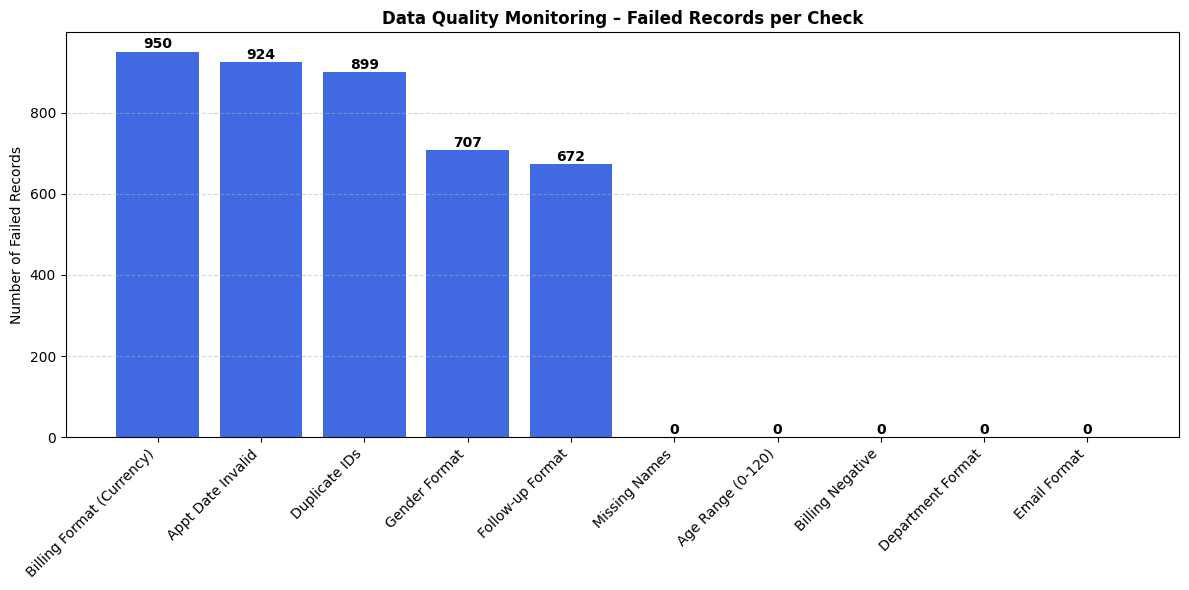

In [4]:
# 5. Quality Checks Implementation
print("QUALITY CHECKS IMPLEMENTATION")
print("="*50)

# 5.1 Completeness (Nulls)
null_counts = df.isnull().sum()
# From DataQuality
null_failures = df['patient_name'].isnull().sum()

# 5.2 Uniqueness
id_dup_count = df['patient_id'].duplicated().sum()
exact_dup_count = df.duplicated().sum()
# From DataQuality
duplicate_failures = df['patient_id'].duplicated().sum()

# 5.3 Range checks
age_range_fail = ((df['age'] < 0) | (df['age'] > 120)).sum()
# From DataQuality
range_failures = ((df['age'] < 0) | (df['age'] > 120)).sum()

billing_num = pd.to_numeric(df['billing_amount'], errors='coerce')
billing_negative = (billing_num < 0).sum()

# 5.4 Format checks (Validity / Consistency)
billing_format_fail = (pd.to_numeric(df['billing_amount'], errors='coerce').isnull() & df['billing_amount'].notnull()).sum()

gender_fail = (~df['gender'].isin(['Male','Female']) & df['gender'].notnull()).sum()

# Date Checks from IS346
appt_dt = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
date_fail = (appt_dt.isnull() & df['appointment_date'].notnull()).sum() + (appt_dt > pd.Timestamp.today()).sum()

# Date Checks from DataQuality (Strict Day/Month/Year Checks)
converted_dates = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
invalid_calendar_dates = converted_dates.isnull() & df['appointment_date'].notnull()
future_dates = converted_dates > pd.Timestamp.today()
date_failures = (invalid_calendar_dates | future_dates).sum()

followup_fail = (~df['follow_up_required'].isin(['Yes','No']) & df['follow_up_required'].notnull()).sum()

expected_departments = ['Cardiology','Neurology','Orthopedics','Pediatrics','General']
dept_fail = (~df['department'].isin(expected_departments) & df['department'].notnull()).sum()

# 5.5 Email format check (dataset has no email column)
if 'email' in df.columns:
    email_pattern = r'^[\\w\\.-]+@[\\w\\.-]+\\.[\\w]{2,}$'
    email_fail = (~df['email'].astype(str).str.match(email_pattern) & df['email'].notnull()).sum()
else:
    email_fail = 0
    print("\nNote: No email column in dataset")

print(f"Total Date errors (violates DD/MM/YYYY, impossible days, or future dates) [DataQuality Calc]: {date_failures}")
print("Quality Checks Completed on Data!")

# --- DISPLAY IS346 CHART & SUMMARY ---
print("\n" + "="*50)
print("IS346 DATA QUALITY CHECK SUMMARY & CHART")
print("="*50)

# Compile IS346 checks
failures_is346 = {
    'Missing Names': null_failures,
    'Duplicate IDs': id_dup_count,
    'Age Range (0-120)': age_range_fail,
    'Billing Negative': billing_negative,
    'Billing Format (Currency)': billing_format_fail,
    'Gender Format': gender_fail,
    'Appt Date Invalid': date_fail,
    'Follow-up Format': followup_fail,
    'Department Format': dept_fail,
    'Email Format': email_fail
}

failures_series = pd.Series(failures_is346).sort_values(ascending=False)
summary_df = pd.DataFrame({'Check': failures_series.index, 'Failed Records': failures_series.values})
display(summary_df)

# Bar chart (IS346)
plt.figure(figsize=(12,6))
bars = plt.bar(failures_series.index, failures_series.values, color='#4169E1')
plt.title('Data Quality Monitoring – Failed Records per Check (IS346)', fontweight='bold')
plt.ylabel('Number of Failed Records')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 1, int(h),
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# --- DISPLAY DATAQUALITY CHART & SUMMARY ---
print("\n" + "="*50)
print("DATAQUALITY MONITORING SYSTEM CHART")
print("="*50)

# Group the failure counts for charting
failures_dq = {
    'Missing Names\\n(Nulls)': null_failures,
    'Duplicate IDs\\n(Uniqueness)': duplicate_failures,
    'Out-of-Range Ages\\n(Validity)': range_failures,
    'Invalid Dates\\n(Format)': date_failures
}

# Create the Matplotlib Bar Chart (DataQuality)
plt.figure(figsize=(10, 6))
bars = plt.bar(failures_dq.keys(), failures_dq.values(), color=['#FF595E', '#FFCA3A', '#8AC926', '#1982C4'])

# titles and labels
plt.title('Data Quality Monitoring System: "Failed Records" (DataQuality)', fontsize=16, fontweight='bold')
plt.ylabel('Number of Failed Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add failure numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')

# background white
plt.gca().set_facecolor('white')
plt.show()
